# ME 144/244: Modeling, Simulation, and Digital Twins of Drone-Based Systems
## Project 7: Aerial Firefighting
## Spring 2026 Semester


In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from animation import Animation
from geneticalgorithm import GeneticAlgorithm
from aerial_sensitivity_analysis import AerialSensitivityAnalyzer

with open('parameters.pkl', 'rb') as f:
    parameters = pickle.load(f)


## Problem 2

In [2]:
LAM_fixed = [ 6.93e1,  0.0 , 1.751e2 ,-1.192e1, 4.29e-3,  1.83e-1 , 2.159e-2 , 6.921e-1, 8.21,  4.878 , 4.85 , 1.5207e3]
try:
    from simulation import Simulation 
    sim_student = Simulation(parameters, LAM_fixed)
    hist_plane_s, hist_parts_s = sim_student.simulate_path_with_nozzles()
    cost_student = sim_student.calculate_cost()
    print(f'Student simulation cost (expect 0.2100): {cost_student:.4f}')
    if abs(cost_student - 0.2100) < 0.001:
        print('PASS — implementation matches reference.')
    else:
        print(f'MISMATCH — check your implementation (reference = 0.2100, yours = {cost_student:.4f}).')
except SyntaxError:
    print('student_simulation.py still has unfilled blanks (SyntaxError).')
    print('Complete all steps before running this cell.')
except Exception as e:
    print(f'Error running student simulation: {e}')

Student simulation cost (expect 0.2100): 0.2100
PASS — implementation matches reference.


Results are saved to `ga_results.pkl` so you only need to run it once 

In [3]:
# Run the GA (skip if ga_results.pkl already exists and you don't want to re-run)
GA = GeneticAlgorithm(parameters)
ga_data = GA.GA(print_bool=True)

with open('ga_results.pkl', 'wb') as f:
    pickle.dump(ga_data, f)

print('GA complete. Results saved to ga_results.pkl.')
print(f'Best cost:  {ga_data["best_cost"][-1]:.4f}')
print(f'Best LAM:   {ga_data["best_p_strings"][0]}')

Generation : 2
Best Cost  : 0.8680392370339526
Generation : 3
Best Cost  : 0.8680392370339526
Generation : 4
Best Cost  : 0.8680392370339526
Generation : 5
Best Cost  : 0.8680392370339526
Generation : 6
Best Cost  : 0.8680392370339526
Generation : 7
Best Cost  : 0.742049882437449
Generation : 8
Best Cost  : 0.3191886834690526
Generation : 9
Best Cost  : 0.29885593727331
Generation : 10
Best Cost  : 0.2524615207059423
Generation : 11
Best Cost  : 0.2524615207059423
Generation : 12
Best Cost  : 0.2524615207059423
Generation : 13
Best Cost  : 0.2524615207059423
Generation : 14
Best Cost  : 0.17303646025952643
Generation : 15
Best Cost  : 0.17303646025952643
Generation : 16
Best Cost  : 0.17303646025952643
Generation : 17
Best Cost  : 0.16971287515082917
Generation : 18
Best Cost  : 0.16167455887304855
Generation : 19
Best Cost  : 0.13313190037912095
Generation : 20
Best Cost  : 0.13099674720015891
GA complete. Results saved to ga_results.pkl.
Best cost:  0.1310
Best LAM:   [6.31775106e+01

In [4]:
# Load saved GA results (use this instead of re-running the GA)
with open('ga_results.pkl', 'rb') as f:
    ga_data = pickle.load(f)

print(f'Best cost:  {ga_data["best_cost"][-1]:.4f}')
print(f'Best LAM:   {ga_data["best_p_strings"][0]}')

Best cost:  0.1310
Best LAM:   [6.31775106e+01 0.00000000e+00 1.77225113e+02 1.18779700e+01
 3.54116922e-03 9.62904966e-02 3.08164137e-02 6.80579278e-01
 8.65330438e+00 9.11238294e+01 4.87522927e+00 1.55803706e+03]


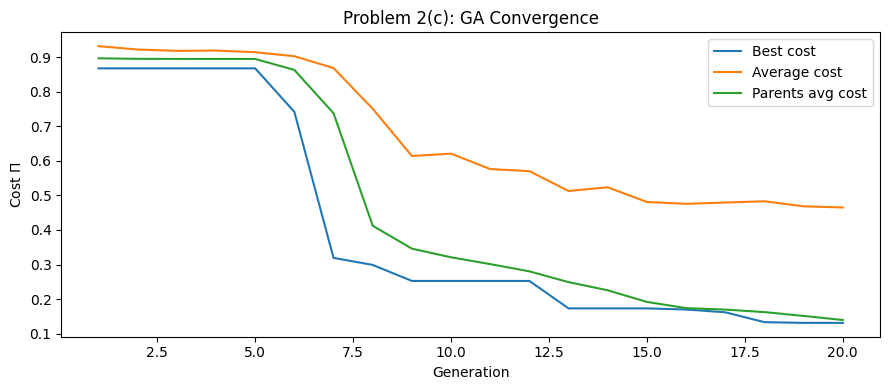

Convergence plot saved to ../animations/ga_convergence.png


In [5]:
# Convergence plot: best cost, average cost, parents average cost vs. generation
gens = range(1, len(ga_data['best_cost']) + 1)

plt.figure(figsize=(9, 4))
plt.plot(gens, ga_data['best_cost'],           label='Best cost')
plt.plot(gens, ga_data['average_cost'],        label='Average cost')
plt.plot(gens, ga_data['parents_average_cost'],label='Parents avg cost')
plt.xlabel('Generation')
plt.ylabel('Cost $\\Pi$')
plt.title('Problem 2(c): GA Convergence')
plt.legend()
plt.tight_layout()
plt.savefig('../animations/ga_convergence.png', dpi=150)
plt.show()
print('Convergence plot saved to ../animations/ga_convergence.png')

Best LAM:  [6.31775106e+01 0.00000000e+00 1.77225113e+02 1.18779700e+01
 3.54116922e-03 9.62904966e-02 3.08164137e-02 6.80579278e-01
 8.65330438e+00 9.11238294e+01 4.87522927e+00 1.55803706e+03]
Best cost: 0.1310


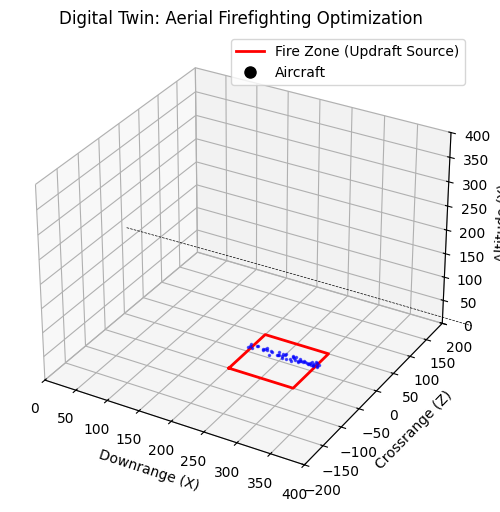

In [6]:
# Run the best design and animate (uncomment animate line to save)
LAM_best = ga_data['best_p_strings'][0]
sim_best = Simulation(parameters, LAM_best)
hist_plane_best, hist_parts_best = sim_best.simulate_path_with_nozzles()

print(f'Best LAM:  {LAM_best}')
print(f'Best cost: {sim_best.calculate_cost():.4f}')

# Uncomment to generate the animation for the optimized design
anim_best = Animation(hist_plane_best, hist_parts_best, parameters)
anim_best.animate_firefighting(title='ga_result', savefig=True)

## Problem 3 

In [7]:
TANK_VOLUME = parameters['TANK_VOLUME']  # 10 m^3

print(f"{'Radius (m)':<15} {'Vol (m^3)':<18} {'N_total':>12}")
print('-' * 47)
for r in [0.05, 0.1, 0.2, 0.01, 0.003, 0.001, 0.0003]:
    vol = (4/3) * np.pi * r**3
    N   = int(TANK_VOLUME / vol)
    print(f'{r:<15.4f} {vol:<18.6e} {N:>12,}')

Radius (m)      Vol (m^3)               N_total
-----------------------------------------------
0.0500          5.235988e-04             19,098
0.1000          4.188790e-03              2,387
0.2000          3.351032e-02                298
0.0100          4.188790e-06          2,387,324
0.0030          1.130973e-07         88,419,412
0.0010          4.188790e-09       2,387,324,146
0.0003          1.130973e-10       88,419,412,828


## Problem 4 

Running sensitivity sweep with default baseline LAM...
Baseline LAM: [69.3, 0.0, 175.1, -11.92, 0.00429, 0.183, 0.02159, 0.6921, 8.21e-06, 48.78, 48.5, 1520.7]
Running 225 simulations...
  1/225 done
  10/225 done
  20/225 done
  30/225 done
  40/225 done
  50/225 done
  60/225 done
  70/225 done
  80/225 done
  90/225 done
  100/225 done
  110/225 done
  120/225 done
  130/225 done
  140/225 done
  150/225 done
  160/225 done
  170/225 done
  180/225 done
  190/225 done
  200/225 done
  210/225 done
  220/225 done
Sweep complete.


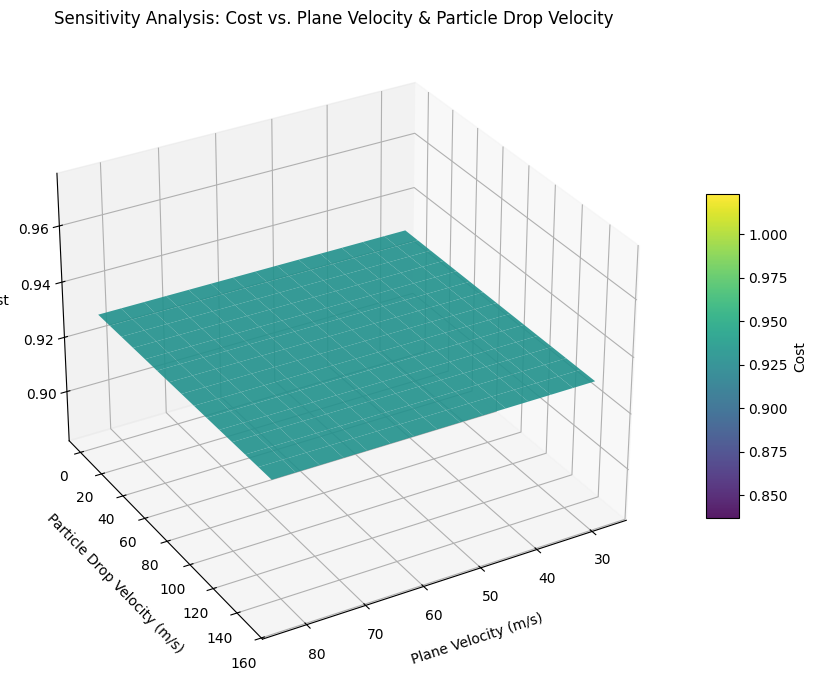

Saved to ../animations/sensitivity_surface.png


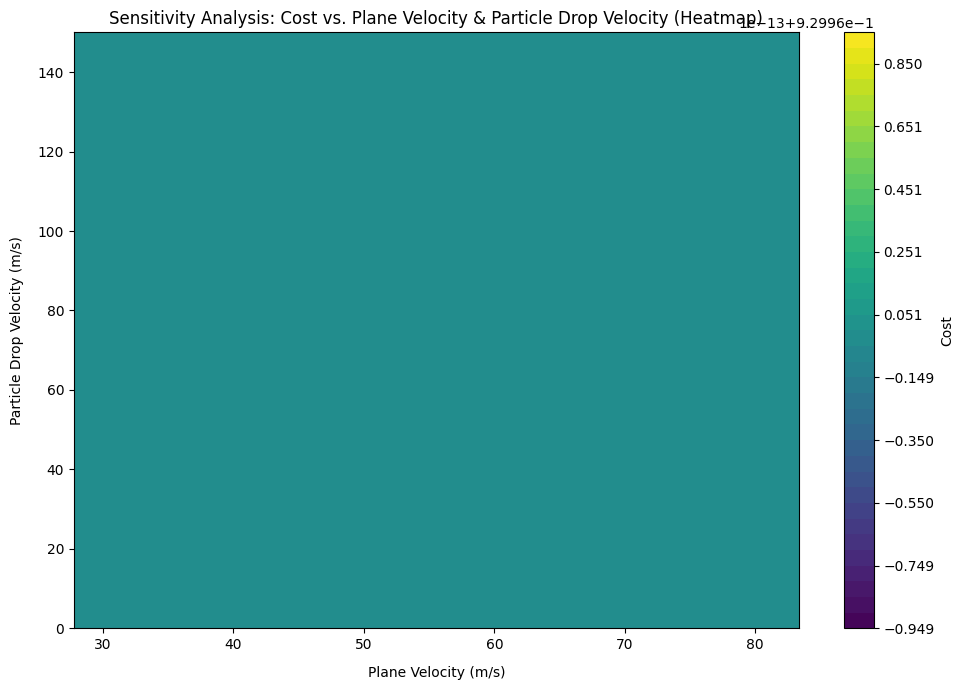

Saved to ../animations/sensitivity_heatmap.png
Done. Surface and heatmap saved to ../animations/


In [8]:
# Sensitivity sweep using the default baseline LAM (ga_results_path = '')
analyzer = AerialSensitivityAnalyzer(parameters, animations_dir='../animations')
base_lam_default = AerialSensitivityAnalyzer.default_base_lam()

print('Running sensitivity sweep with default baseline LAM...')
print(f'Baseline LAM: {base_lam_default}')

results_default = analyzer.run_velocity_drop_velocity(
    base_lam=base_lam_default,
    make_plots=True,
)
print('Done. Surface and heatmap saved to ../animations/')

Running sensitivity sweep with GA best LAM...
GA best LAM: [np.float64(63.177510620689084), np.float64(0.0), np.float64(177.22511313167814), np.float64(11.877970003930725), np.float64(0.003541169215935021), np.float64(0.09629049661654679), np.float64(0.030816413690093296), np.float64(0.6805792781269587), np.float64(8.653304376213555), np.float64(91.12382940955642), np.float64(4.8752292685446825), np.float64(1558.0370559616817)]
Running 225 simulations...
  1/225 done
  10/225 done
  20/225 done
  30/225 done
  40/225 done
  50/225 done
  60/225 done
  70/225 done
  80/225 done
  90/225 done
  100/225 done
  110/225 done
  120/225 done
  130/225 done
  140/225 done
  150/225 done
  160/225 done
  170/225 done
  180/225 done
  190/225 done
  200/225 done
  210/225 done
  220/225 done
Sweep complete.


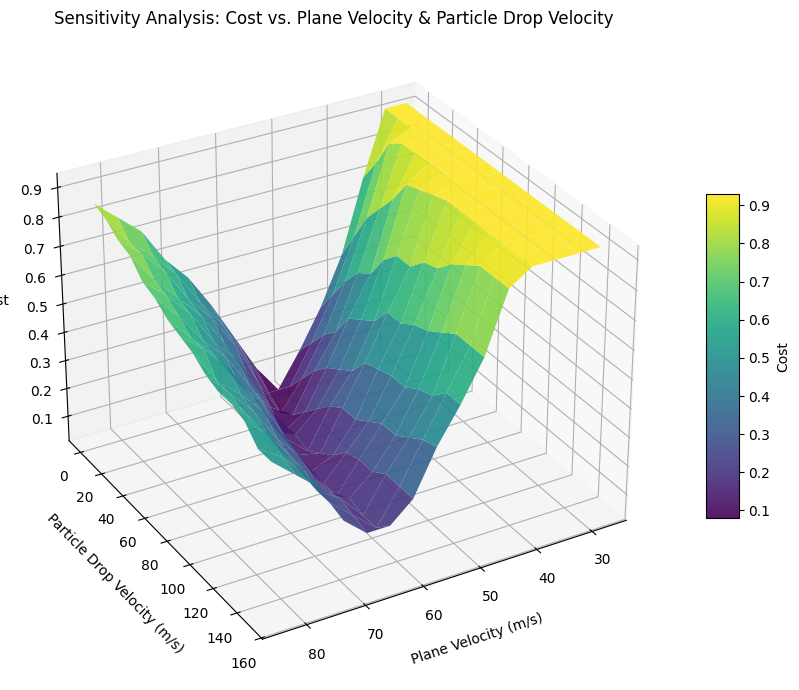

Saved to ../animations/sensitivity_surface.png


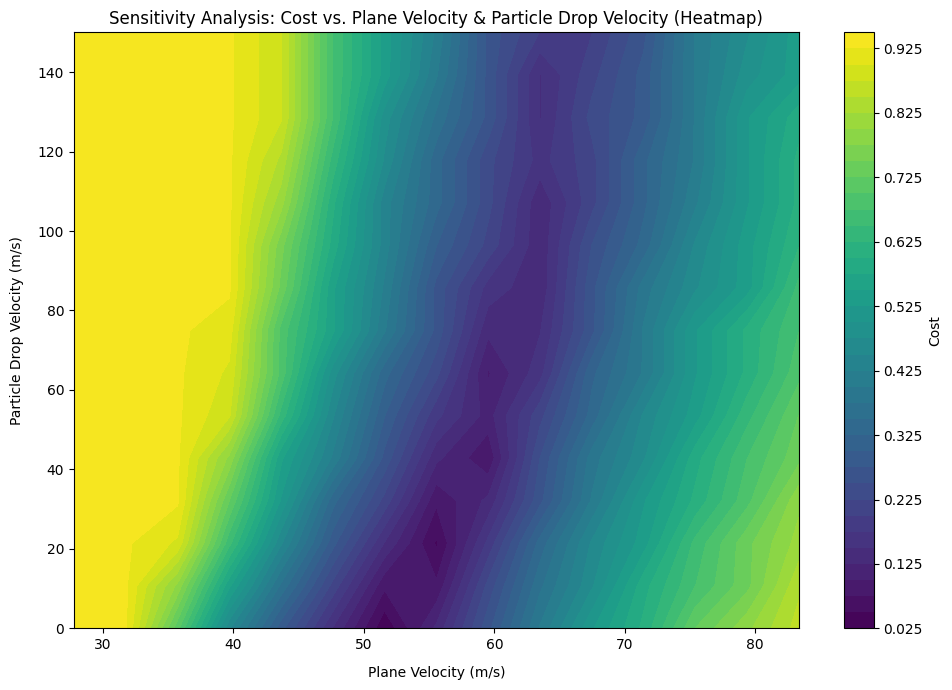

Saved to ../animations/sensitivity_heatmap.png
Done. Surface and heatmap saved to ../animations/


In [9]:
# Sensitivity sweep using the GA best LAM
base_lam_ga = AerialSensitivityAnalyzer.load_ga_best_lam(
    ga_results_path='ga_results.pkl',
    fallback=AerialSensitivityAnalyzer.default_base_lam(),
)

print('Running sensitivity sweep with GA best LAM...')
print(f'GA best LAM: {base_lam_ga}')

results_ga = analyzer.run_velocity_drop_velocity(
    base_lam=base_lam_ga,
    make_plots=True,
)
print('Done. Surface and heatmap saved to ../animations/')

In [10]:
LAM = [ 6.93e1,  0.0 , 1.751e2 ,-1.192e1, 4.29e-3,  1.83e-1 , 2.159e-2 , 6.921e-1, 8.21e-6,  4.878e1 , 4.85e+1 , 1.5207e3]